# Stability Analysis - MyNordic Package Parameter Sweep

Start from the `MyNordic` package model (Nordic-32 test system, 20 detailed synchronous machines), change one parameter, and compare the modes across the sweep. Package-model counterpart of `StabilityAnalysis_BESS`, using a local daeMode-free copy of the package under `models/`.

Set `REINITIALIZE_EACH_CASE` to choose whether the package is initialized once before the sweep, or reinitialized after each parameter update. For parameters that do not move the operating point (e.g. inertia `H` or control gains), initializing once is enough; reinitialize when the swept parameter changes the steady state (impedances, setpoints, power/voltage references).

In [1]:
include("../FullWorkflow/scripts/dictionaries.jl")
include("../FullWorkflow/scripts/helpers.jl")
include("../ParametricStudies/scripts/parametric_study_helpers.jl")
include("../ParametricStudies/scripts/package_model_initialization.jl")

using .FullWorkflowHelpers
using .ParametricStudyHelpers
using .PackageModelInitialization
using OMJulia, LinearAlgebra, DataFrames

## User Configuration


In [2]:
MODEL = "MyNordic.TestCase"
SOURCE_PACKAGE = split(MODEL, ".")[1]
MODEL_DIR = abspath(joinpath("models", SOURCE_PACKAGE))
MODELS_PKG_PATH = joinpath(MODEL_DIR, "package.mo")

DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

SWEEP_COMPONENT = "vrNordic_g20"
SWEEP_PARAMETER = "KTgr"
SWEEP_VALUES = [100.0, 1000.0, 2000.0, 2500.0]

# KTgr (AVR gain of generator g20's voltage regulator) is a dynamics-only parameter:
# it does not move the operating point, so the base case is initialized once and
# reused for every sweep value. (High KTgr drives an AVR/exciter mode unstable via a
# Hopf bifurcation near KTgr = 2450; nominal KTgr = 70.)
REINITIALIZE_EACH_CASE = false

# The events (node fault + line disconnection) were removed from this local copy,
# so the model stays at its equilibrium and any LINEARIZATION_TIME gives the
# operating-point linearization. 0.5 s is a small, safe value.
LINEARIZATION_TIME = "0.5"
MODE_TOL = 1e-8

# OMJulia's linearize() does NOT apply the model's __OpenModelica_simulationFlags,
# so pass the critical runtime flag explicitly. newtonMaxStepFactor bounds the
# Newton step so the initialization solver does not overshoot into invalid
# saturation roots (negative base ^ non-integer exponent nd/nq of the machines).
# NOTE: pass a SINGLE flag - OMJulia sends simflags as one argv, so space-separated
# flags would not be parsed.
LINEARIZATION_SIMFLAGS = "-newtonMaxStepFactor=0.1"

# OMC refuses to build the linear model when the system exceeds a size threshold
# ("System too big. Use compiler flag --maxSizeLinearization"). Raise it above the
# Nordic system size (~1e3) via the ModelicaSystem commandLineOptions below.
LINEARIZATION_MAXSIZE = 50000

# Nordic synchronous generators each need their _INIT profile.
INIT_MODEL_BY_COMPONENT = Dict{String, String}(
    "g01" => "GeneratorSynchronousExt3W_INIT",
    "g02" => "GeneratorSynchronousExt3W_INIT",
    "g03" => "GeneratorSynchronousExt3W_INIT",
    "g04" => "GeneratorSynchronousExt3W_INIT",
    "g05" => "GeneratorSynchronousExt3W_INIT",
    "g06" => "GeneratorSynchronousExt4W_INIT",
    "g07" => "GeneratorSynchronousExt4W_INIT",
    "g08" => "GeneratorSynchronousExt3W_INIT",
    "g09" => "GeneratorSynchronousExt3W_INIT",
    "g10" => "GeneratorSynchronousExt3W_INIT",
    "g11" => "GeneratorSynchronousExt3W_INIT",
    "g12" => "GeneratorSynchronousExt3W_INIT",
    "g13" => "GeneratorSynchronousExt3W_INIT",
    "g14" => "GeneratorSynchronousExt4W_INIT",
    "g15" => "GeneratorSynchronousExt4W_INIT",
    "g16" => "GeneratorSynchronousExt4W_INIT",
    "g17" => "GeneratorSynchronousExt4W_INIT",
    "g18" => "GeneratorSynchronousExt4W_INIT",
    "g19" => "GeneratorSynchronousExt3W_INIT",
    "g20" => "GeneratorSynchronousExt3W_INIT",
)

SLACK_COMPONENT = "g20"

OUTPUT_DIR = abspath("outputs/MyNordic_KTgr_stability_sweep");

## Prepare OpenModelica Session


In [3]:
BUILD_OUTPUT_DIR = joinpath(OUTPUT_DIR, "omc-build")

isfile(MODELS_PKG_PATH) || error("Package file not found: $MODELS_PKG_PATH")
isfile(DYNAWO_PKG_PATH) || error("Dynawo package not found: $DYNAWO_PKG_PATH")
isfile(MODELICA_PKG_PATH) || error("Modelica package not found: $MODELICA_PKG_PATH")

rm(OUTPUT_DIR; recursive = true, force = true)
mkpath(BUILD_OUTPUT_DIR)

StudyOMC = OMJulia.OMCSession()
load_modelica_file!(
    StudyOMC,
    MODELS_PKG_PATH,
    MODELICA_PKG_PATH,
    DYNAWO_PKG_PATH,
)
omc_call(StudyOMC, "checkModel($MODEL)", parsed = false)

MODEL_CHAIN = get_inheritance_chain(StudyOMC, MODEL)

parameter_models = String[]
for model in MODEL_CHAIN
    model_name = String(model)
    if haskey(get_all_components(StudyOMC, model_name), SWEEP_COMPONENT)
        push!(parameter_models, model_name)
    end
end

isempty(parameter_models) && error("Component $SWEEP_COMPONENT was not found in the inheritance chain for $MODEL")
PARAMETER_MODEL = first(parameter_models)
# (sin OMJulia.quit aqui: reutilizamos StudyOMC en la celda siguiente)

println("Package model checked successfully.")

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.xqqKALg8Jh"


Package model checked successfully.


## Initialize the Base Package

When `REINITIALIZE_EACH_CASE` is `false`, initialize the base package once here and reuse it for every sweep case. When it is `true`, this cell only closes the session opened above.

In [4]:
if !REINITIALIZE_EACH_CASE
    base_initialized_case = initialize_loaded_package_model(
        StudyOMC;
        source_model = MODEL,
        model_chain = MODEL_CHAIN,
        case_name = SOURCE_PACKAGE * "_base",
        output_dir = OUTPUT_DIR,
        modelica_package_path = MODELICA_PKG_PATH,
        dynawo_package_path = DYNAWO_PKG_PATH,
        init_model_by_component = INIT_MODEL_BY_COMPONENT,
        slack_component = SLACK_COMPONENT,
    )

    base_initialized_package_file = base_initialized_case.initialized_package_file
    base_initialized_model = base_initialized_case.initialized_model

    base_initialized_model_map = initialized_name_map(
        MODEL_CHAIN,
        base_initialized_case.initialized_package,
    )
    base_parameter_model = base_initialized_model_map[PARAMETER_MODEL]
    println("Base package initialized once: ", base_initialized_model)
end

OMJulia.quit(StudyOMC)

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.ieW223PRuO"


Base package initialized once: MyNordic_base_initialized.TestCase_initialized


## Run the Parameter Sweep


In [5]:
A_matrices = Dict{Float64, Matrix{Float64}}()
linear_states_by_case = Dict{Float64, Vector{String}}()
linearization_sizes = NamedTuple[]

for value in SWEEP_VALUES
    label = case_label(value)
    parameter_name = replace(SWEEP_PARAMETER, "." => "_")
    case_model = join([SOURCE_PACKAGE, SWEEP_COMPONENT, parameter_name, label], "_")
    case_build_dir = joinpath(BUILD_OUTPUT_DIR, case_model)
    mkpath(case_build_dir)

    StudyOMC = OMJulia.OMCSession()

    try
        if REINITIALIZE_EACH_CASE
            load_modelica_file!(
                StudyOMC,
                MODELS_PKG_PATH,
                MODELICA_PKG_PATH,
                DYNAWO_PKG_PATH,
            )

            omc_call(
                StudyOMC,
                "setParameterValue($(PARAMETER_MODEL), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
                parsed = false,
            )

            initialized_case = initialize_loaded_package_model(
                StudyOMC;
                source_model = MODEL,
                model_chain = MODEL_CHAIN,
                case_name = case_model,
                output_dir = OUTPUT_DIR,
                modelica_package_path = MODELICA_PKG_PATH,
                dynawo_package_path = DYNAWO_PKG_PATH,
                init_model_by_component = INIT_MODEL_BY_COMPONENT,
                slack_component = SLACK_COMPONENT,
            )

            linearized_model = initialized_case.initialized_model
        else
            load_modelica_file!(
                StudyOMC,
                base_initialized_package_file,
                MODELICA_PKG_PATH,
                DYNAWO_PKG_PATH,
            )

            omc_call(
                StudyOMC,
                "setParameterValue($(base_parameter_model), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
                parsed = false,
            )

            linearized_model = base_initialized_model
        end

        ModelicaSystem(
            StudyOMC,
            nothing,
            linearized_model,
            [MODELICA_PKG_PATH, DYNAWO_PKG_PATH];
            commandLineOptions = "--maxSizeLinearization=$(LINEARIZATION_MAXSIZE)",
            customBuildDirectory = case_build_dir,
        )

        setLinearizationOptions(
            StudyOMC,
            [
                "startTime=0.0",
                "stopTime=$LINEARIZATION_TIME",
                "stepSize=0.001",
                "tolerance=1e-6",
            ],
        )

        matrices = linearize(StudyOMC; lintime = LINEARIZATION_TIME, simflags = LINEARIZATION_SIMFLAGS, verbose = false)

        A_matrices[value] = Matrix{Float64}(Float64.(matrices[1]))
        linear_states_by_case[value] = String.(getLinearStates(StudyOMC))

        if value == first(SWEEP_VALUES)
            push!(linearization_sizes, (
                A = join(string.(size(matrices[1])), "x"),
                B = join(string.(size(matrices[2])), "x"),
                C = join(string.(size(matrices[3])), "x"),
                D = join(string.(size(matrices[4])), "x"),
            ))
        end
    finally
        OMJulia.quit(StudyOMC)
    end

    println("Finished $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
end

linear_states = linear_states_by_case[first(SWEEP_VALUES)]

for value in SWEEP_VALUES
    if linear_states_by_case[value] != linear_states
        error("Linear state order changed for $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
    end
end

println("Linearization sweep finished.")

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.jGbAjpOLiT"
  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.


Finished vrNordic_g20.KTgr = 100.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.wBrfWjfWEt"


Finished vrNordic_g20.KTgr = 1000.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.1qzBGvgNjG"


Finished vrNordic_g20.KTgr = 2000.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.lPky9yH0nB"


Finished vrNordic_g20.KTgr = 2500.0
Linearization sweep finished.


## Linearization Summary


In [6]:
sizes = linearization_sizes[1]

linearization_summary = DataFrame([(
    n_states = length(linear_states),
    size_A = sizes.A,
    size_B = sizes.B,
    size_C = sizes.C,
    size_D = sizes.D,
)])

display(linearization_summary)


Row,n_states,size_A,size_B,size_C,size_D
,Int64,String,String,String,String
1,320,320x320,320x0,0x320,0x0


## Analyze Modes


In [7]:
mode_rows = NamedTuple[]
summary_rows = NamedTuple[]

for value in SWEEP_VALUES
    A = A_matrices[value]

    eigenvalues = eigvals(A)
    real_parts = real.(eigenvalues)

    for (mode_index, lambda) in enumerate(eigenvalues)
        real_part = real(lambda)
        imag_part = imag(lambda)

        stability = if real_part > MODE_TOL
            "unstable"
        elseif real_part < -MODE_TOL
            "stable"
        else
            "marginal"
        end

        push!(mode_rows, (
            parameter_value = value,
            mode = mode_index,
            real_part = real_part,
            imag_part = imag_part,
            stability = stability,
        ))
    end

    push!(summary_rows, (
        parameter_value = value,
        max_real_part = maximum(real_parts),
        unstable_modes = count(real_parts .> MODE_TOL),
        marginal_modes = count(abs.(real_parts) .<= MODE_TOL),
        stable_modes = count(real_parts .< -MODE_TOL),
    ))
end

mode_df = sort(DataFrame(mode_rows), [:parameter_value, :mode])
stability_summary = sort(DataFrame(summary_rows), :parameter_value)

println("Mode analysis finished.")


Mode analysis finished.


## Check Unstable Modes


In [8]:
unstable_modes = Int[]

for mode in sort(unique(mode_df.mode))
    rows_for_mode = mode_df[mode_df.mode .== mode, :]

    if any(rows_for_mode.stability .== "unstable")
        push!(unstable_modes, mode)
    end
end

unstable_mode_table = DataFrame(mode = unstable_modes)

for value in SWEEP_VALUES
    column_name = Symbol("$SWEEP_PARAMETER=$(value)")
    stability_values = String[]

    for mode in unstable_modes
        rows_for_mode = mode_df[(mode_df.mode .== mode) .& (mode_df.parameter_value .== value), :]
        push!(stability_values, rows_for_mode.stability[1])
    end

    unstable_mode_table[!, column_name] = stability_values
end

unstable_mode_rows = in.(mode_df.mode, Ref(unstable_modes))
unstable_mode_df = sort(mode_df[unstable_mode_rows, :], [:mode, :parameter_value])

println("Unstable-mode check finished.")


Unstable-mode check finished.


## Modes


In [9]:
println("Stability summary")
display(stability_summary)

println("Modes that become unstable")
display(unstable_mode_table)


Stability summary


Row,parameter_value,max_real_part,unstable_modes,marginal_modes,stable_modes
,Float64,Float64,Int64,Int64,Int64
1,100.0,9.84537e-16,0,45,275
2,1000.0,0.0,0,45,275
3,2000.0,0.0,0,45,275
4,2500.0,0.030568,2,45,273


Modes that become unstable


Row,mode,KTgr=100.0,KTgr=1000.0,KTgr=2000.0,KTgr=2500.0
,Int64,String,String,String,String
1,319,marginal,marginal,marginal,unstable
2,320,marginal,marginal,marginal,unstable


## Mode Plots


WebIO._IJuliaInit()

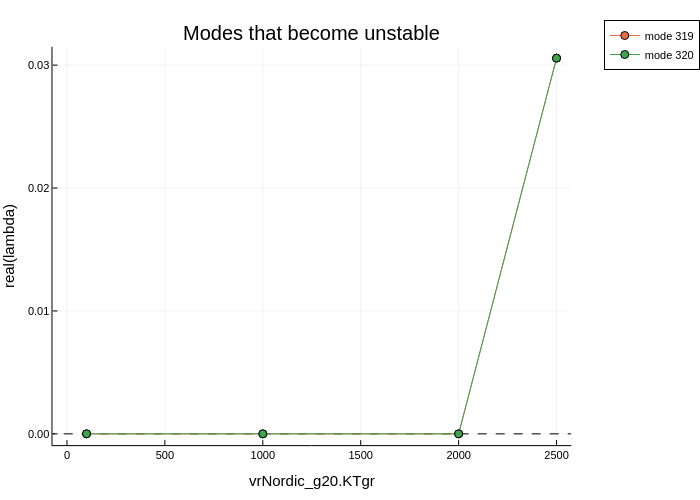

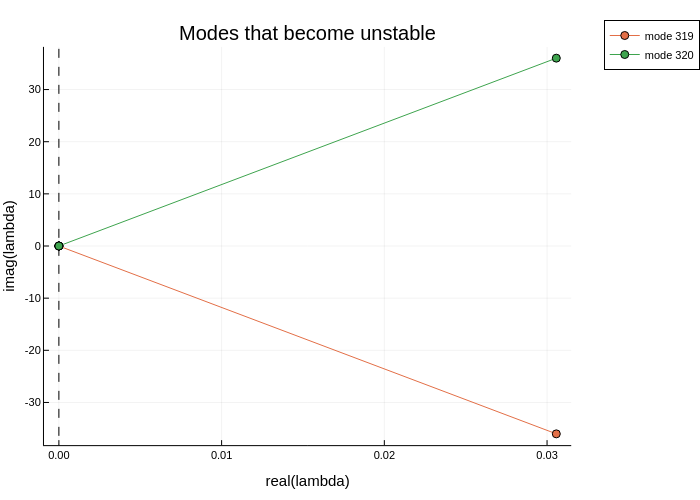

In [10]:
using Plots

plotlyjs()

if isempty(unstable_modes)
    println("No modes become unstable for these sweep values.")
else
    real_part_plot = plot(
        xlabel = "$SWEEP_COMPONENT.$SWEEP_PARAMETER",
        ylabel = "real(lambda)",
        title = "Modes that become unstable",
        legend = :outertopright,
    )
    hline!(real_part_plot, [0.0], line = (:dash, :black), label = "")

    for mode in unstable_modes
        mode_data = unstable_mode_df[unstable_mode_df.mode .== mode, :]
        plot!(
            real_part_plot,
            mode_data.parameter_value,
            mode_data.real_part,
            marker = :circle,
            label = "mode $mode",
        )
    end

    display(real_part_plot)

    complex_plane_plot = plot(
        xlabel = "real(lambda)",
        ylabel = "imag(lambda)",
        title = "Modes that become unstable",
        legend = :outertopright,
    )
    vline!(complex_plane_plot, [0.0], line = (:dash, :black), label = "")

    for mode in unstable_modes
        mode_data = unstable_mode_df[unstable_mode_df.mode .== mode, :]
        plot!(
            complex_plane_plot,
            mode_data.real_part,
            mode_data.imag_part,
            marker = :circle,
            label = "mode $mode",
        )
    end

    display(complex_plane_plot)
end
